In [3]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from src import get_brats_loaders

# 1. Loader initialization
train_loader, val_loader = get_brats_loaders(
    csv_path="../data_inventory.csv", 
    batch_size=2
)

print(f"Loaders ready. Train batches: {len(train_loader)}")

Loaders ready. Train batches: 540


Starting preview of 3 iterations...


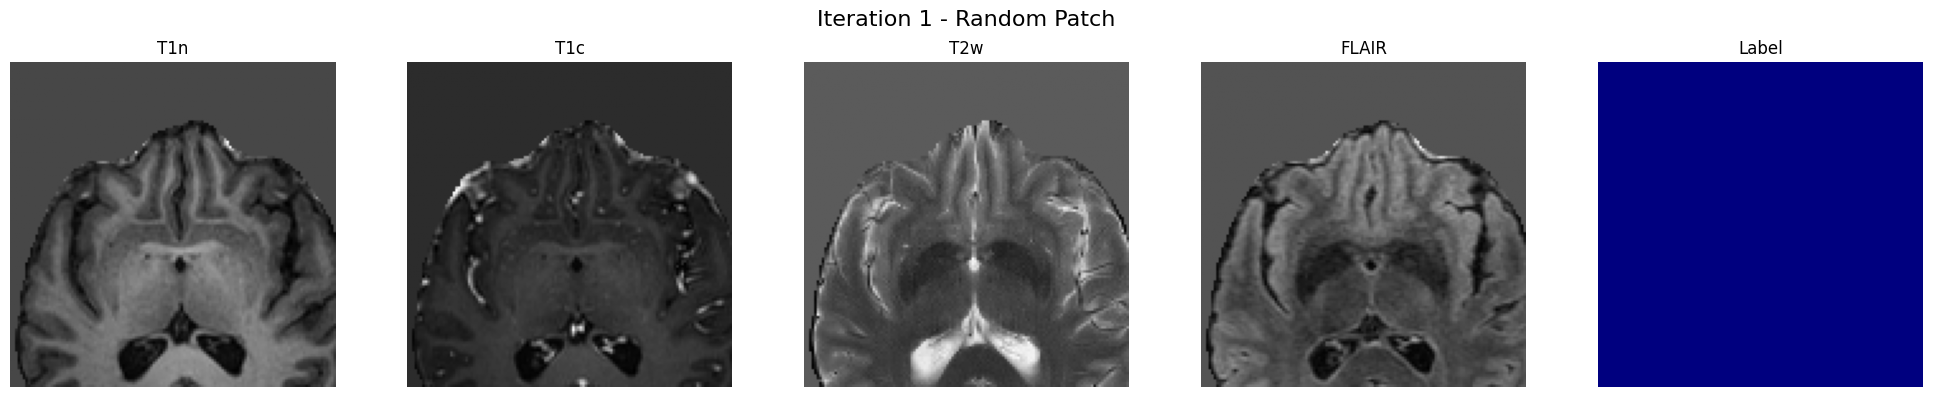

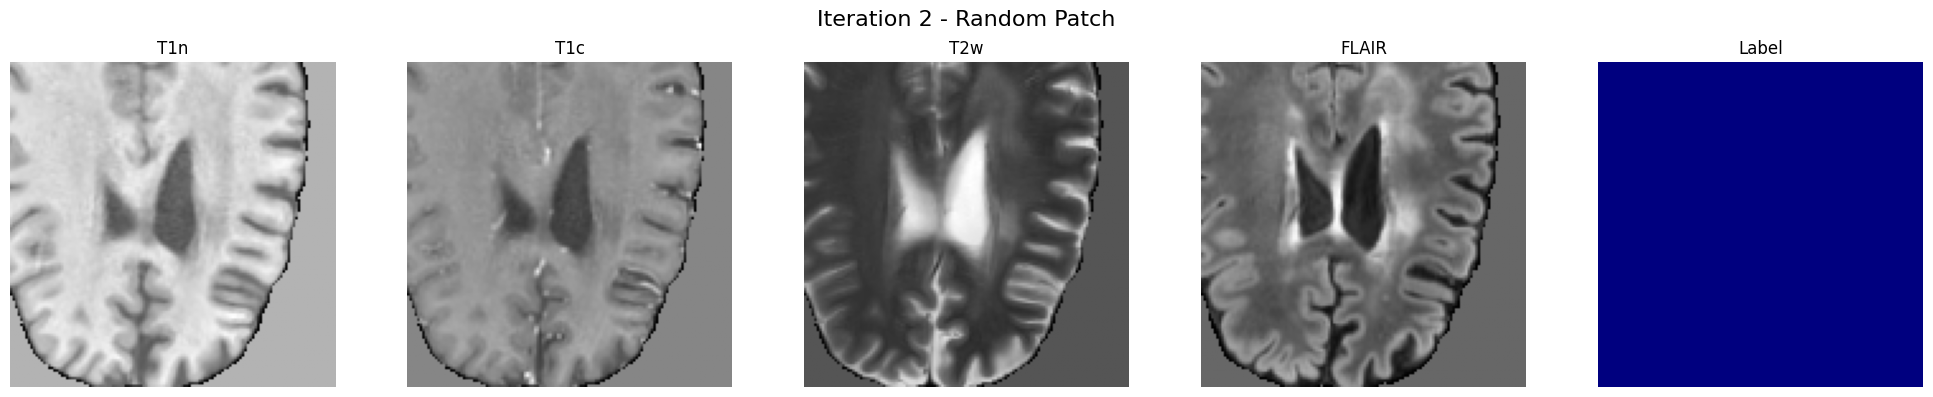

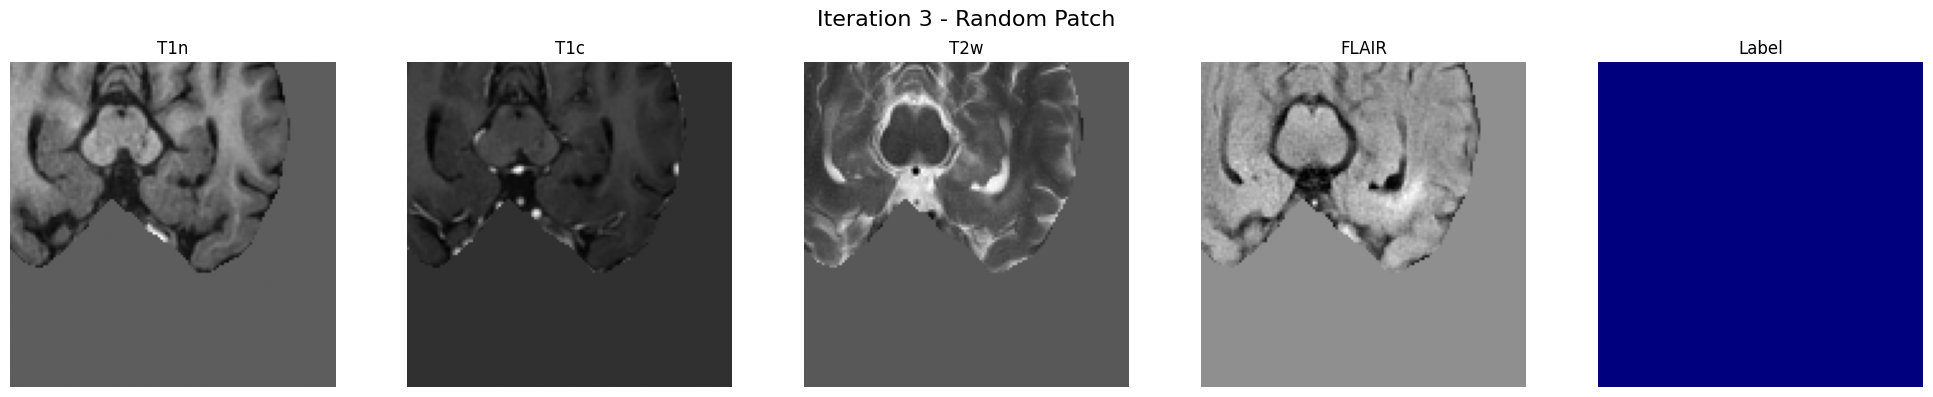

Preview finished.


In [6]:
import matplotlib.pyplot as plt
import numpy as np

num_iterations = 3
modalities = ["T1n", "T1c", "T2w", "FLAIR", "Label"]
slice_idx = 64 # Middle slice of the 128x128x128 volume

print(f"Starting preview of {num_iterations} iterations...")

for i, batch in enumerate(train_loader):
    if i >= num_iterations:
        break
    
    # Data from the current batch
    images = batch["image"] # [Batch, 4, 128, 128, 128]
    labels = batch["label"] # [Batch, 1, 128, 128, 128]
    
    # Selecting the first patient from the batch [index 0]
    img_tensor = images[0].cpu().numpy()
    lbl_tensor = labels[0].cpu().numpy()
    
    # Creating a row of plots for this iteration
    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    fig.suptitle(f"Iteration {i+1} - Random Patch", fontsize=16)
    
    for m in range(4):
        # Rotating 90 degrees for upright orientation
        axes[m].imshow(np.rot90(img_tensor[m, :, :, slice_idx]), cmap='gray')
        axes[m].set_title(modalities[m])
        axes[m].axis('off')

    # Segmentation Mask (Label)
    axes[4].imshow(np.rot90(lbl_tensor[0, :, :, slice_idx]), cmap='jet')
    axes[4].set_title(modalities[4])
    axes[4].axis('off')
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.85) # Adjusting space for the title
    plt.show()

print("Preview finished.")

In [7]:
from monai.losses import DiceLoss
import torch.optim as optim
from src import get_model

# 1. Define the loss function
# sigmoid=True because BraTS classes are not mutually exclusive (nested tumor regions)
loss_function = DiceLoss(
    smooth_nr=1e-5, 
    smooth_dr=1e-5, 
    squared_pred=True, 
    to_onehot_y=False, 
    sigmoid=True
)

# 2. Initialize the model
model = get_model()

# 3. Define the optimizer
optimizer = optim.Adam(model.parameters(), lr=1e-4)

print("Loss function and optimizer are ready for training.")

Loss function and optimizer are ready for training.


In [5]:
import torch
import os

os.environ['HSA_OVERRIDE_GFX_VERSION'] = '10.3.0'

print(f"PyTorch version: {torch.__version__}")
print(f"ROCm/CUDA available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"Current Device ID: {torch.cuda.current_device()}")
    
    x = torch.tensor([1.0, 2.0]).to("cuda")
    print(f"Test tensor on GPU: {x}")
else:

    print("GPU not found! Check your drivers and ROCm installation.")

PyTorch version: 2.11.0+rocm7.2
ROCm/CUDA available: True
GPU Name: AMD Radeon RX 6800M
Current Device ID: 0
Test tensor on GPU: tensor([1., 2.], device='cuda:0')
